In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("Downloads/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [47]:
df.shape

(918, 12)

In [48]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [49]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [50]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [51]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [52]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [53]:
num_cols = df.select_dtypes(include = 'number').columns

In [54]:
num_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

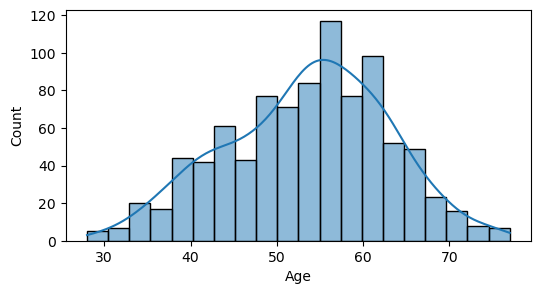

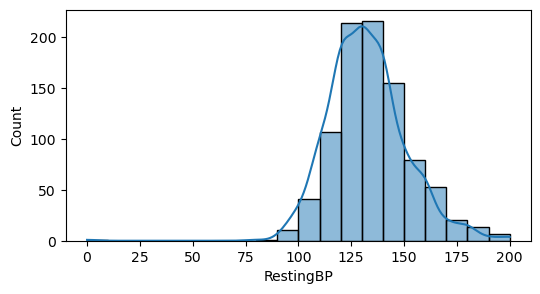

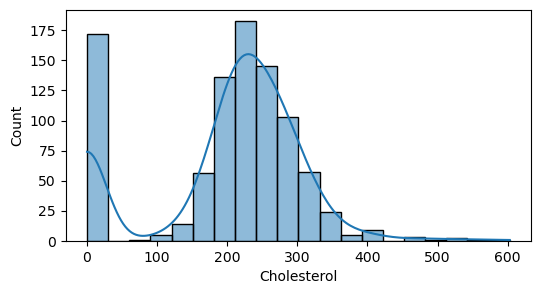

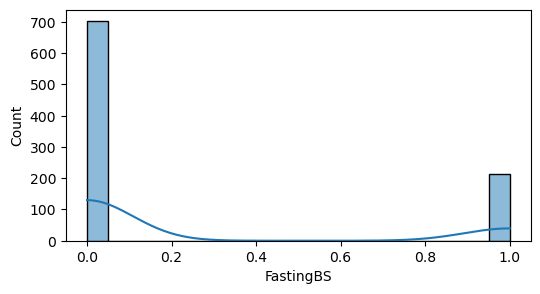

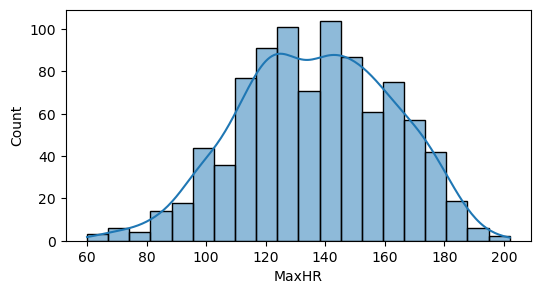

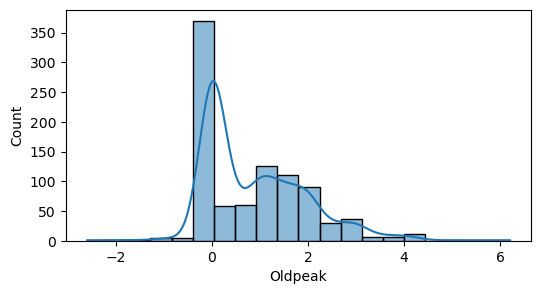

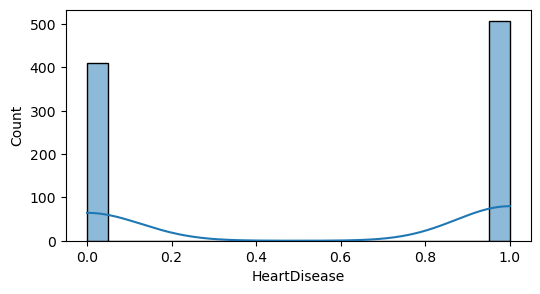

In [55]:
for col in num_cols:
    plt.figure(figsize = (6,3))
    sns.histplot(df[col] , bins = 20 , kde = True)
    plt.show()

In [56]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [57]:
ch_mean = df.loc[df['Cholesterol'] != 0 ,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0 , ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [58]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [59]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [60]:
(df['RestingBP'] == 0).any()

np.True_

In [61]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,244.64,0,Normal,155,N,1.5,Flat,1


In [62]:
ch_mean = df.loc[df['RestingBP'] != 0 ,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0 , ch_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [63]:
(df['RestingBP'] == 0).any()

np.False_

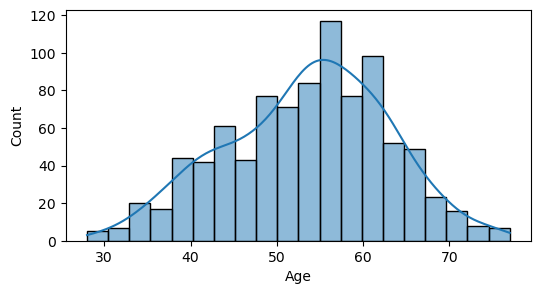

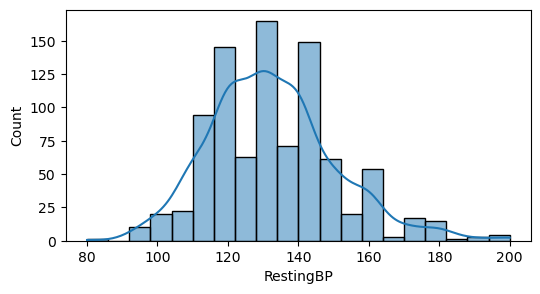

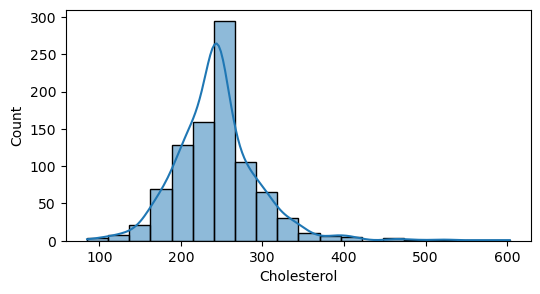

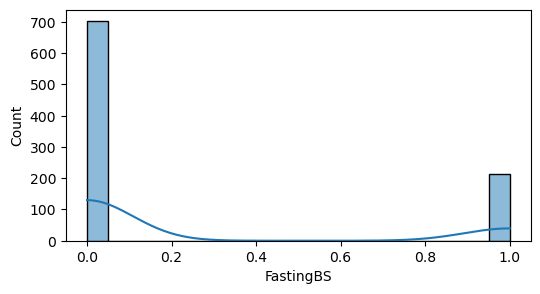

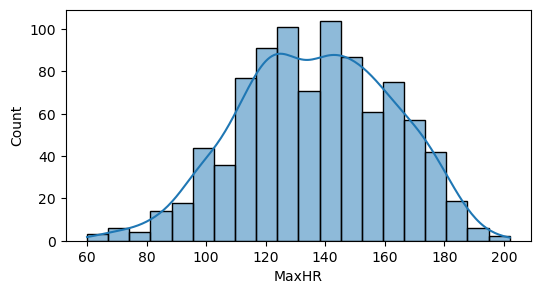

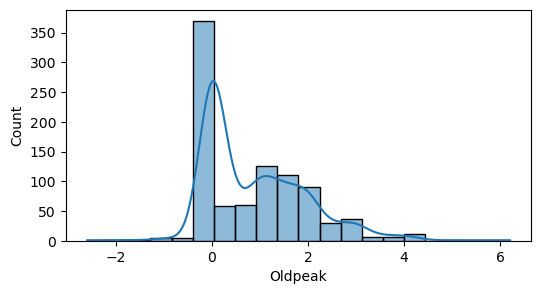

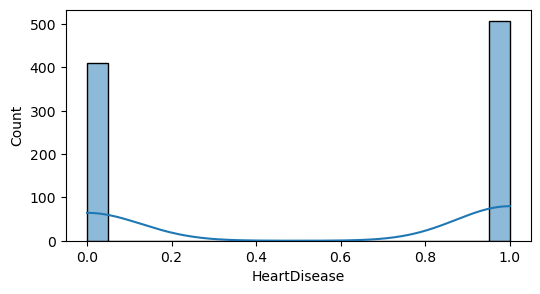

In [64]:
for col in num_cols:
    plt.figure(figsize = (6,3))
    sns.histplot(df[col] , bins = 20 , kde = True)
    plt.show()

In [65]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [66]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [67]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

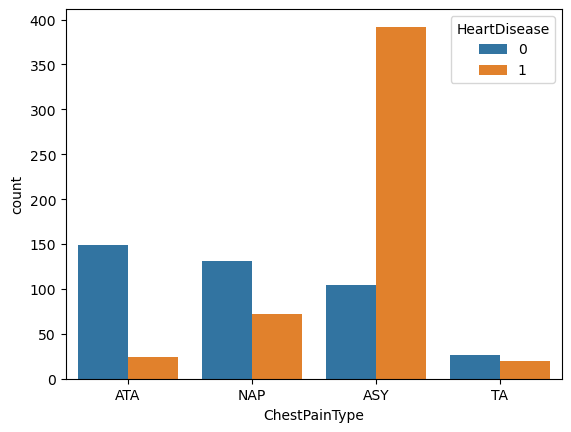

In [68]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

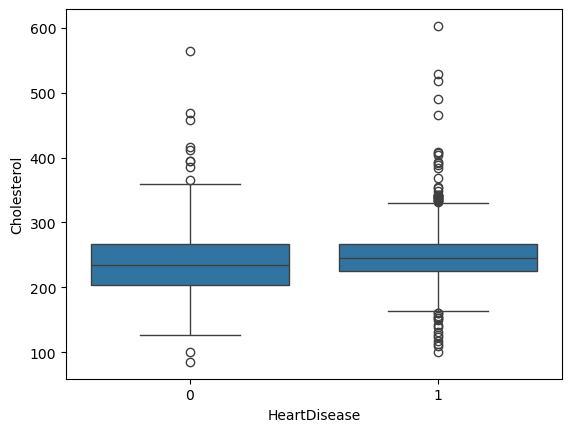

In [69]:
sns.boxplot( x = 'HeartDisease' , y = 'Cholesterol' , data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

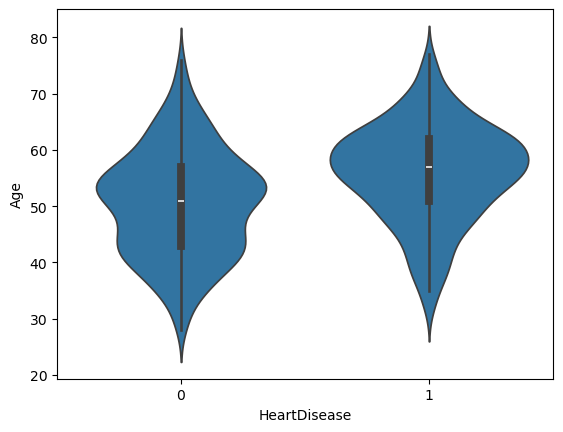

In [70]:
sns.violinplot(x = 'HeartDisease' , y = 'Age' , data = df)

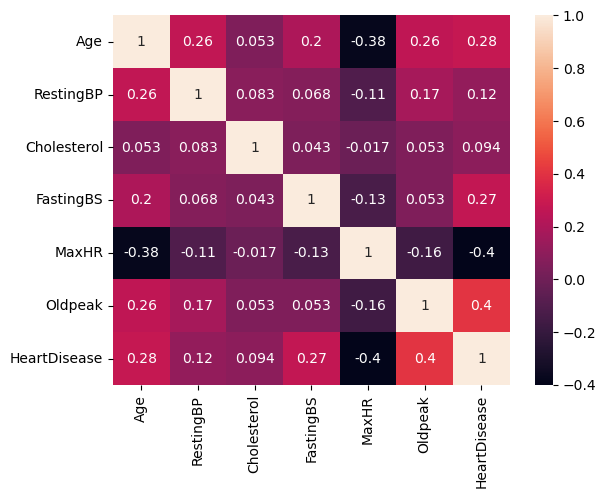

In [71]:
sns.heatmap(df.corr(numeric_only = True) ,annot = True)
plt.show()

In [72]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [73]:
df_cleaned = df.copy()

In [74]:
df_cleaned = df_cleaned.rename(columns = {
    'Sex' : 'isMale'
})
df_cleaned['isMale'] = df_cleaned['isMale'].map({'M' : 1 , 'F' : 0})


In [75]:
df_cleaned['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [76]:
df_cleaned['ExerciseAngina'] = df_cleaned['ExerciseAngina'].map({'Y': 1, 'N': 0})

In [77]:
df_cleaned.head()

,Age,isMale,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140.0,289.0,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160.0,180.0,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130.0,283.0,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138.0,214.0,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150.0,195.0,0,Normal,122,0,0.0,Up,0


In [78]:
df_encoded = pd.get_dummies(df_cleaned)
df_encoded

,Age,isMale,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,0,160.0,180.0,0,156,0,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,1,130.0,283.0,0,98,0,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,0,138.0,214.0,0,108,1,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,1,150.0,195.0,0,122,0,0.0,0,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110.0,264.0,0,132,0,1.2,1,False,False,False,True,False,True,False,False,True,False
914,68,1,144.0,193.0,1,141,0,3.4,1,True,False,False,False,False,True,False,False,True,False
915,57,1,130.0,131.0,0,115,1,1.2,1,True,False,False,False,False,True,False,False,True,False
916,57,0,130.0,236.0,0,174,0,0.0,1,False,True,False,False,True,False,False,False,True,False


In [79]:
df_encoded = df_encoded.astype(int)

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['Age','RestingBP','Cholesterol','MaxHR', 'Oldpeak']

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [81]:
df_encoded

,Age,isMale,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,0.414885,0.834754,0,1.382928,0,-0.727592,0,0,1,0,0,0,1,0,0,0,1
1,-0.478484,0,1.527224,-1.210675,0,0.754157,0,0.282891,1,0,0,1,0,0,1,0,0,1,0
2,-1.751359,1,-0.141284,0.722161,0,-1.525138,0,-0.727592,0,0,1,0,0,0,0,1,0,0,1
3,-0.584556,0,0.303651,-0.572651,0,-1.132156,1,0.282891,1,1,0,0,0,0,1,0,0,1,0
4,0.051881,1,0.971054,-0.929194,0,-0.581981,0,-0.727592,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,1,-1.253622,0.365619,0,-0.188999,0,0.282891,1,0,0,0,1,0,1,0,0,1,0
914,1.536902,1,0.637353,-0.966725,1,0.164684,0,2.303858,1,1,0,0,0,0,1,0,0,1,0
915,0.370100,1,-0.141284,-2.130180,0,-0.857069,1,0.282891,1,1,0,0,0,0,1,0,0,1,0
916,0.370100,0,-0.141284,-0.159813,0,1.461525,0,-0.727592,1,0,1,0,0,1,0,0,0,1,0


Feature Engeenering and Extraction

In [89]:
from scipy.stats import pearsonr
num_cols = df_encoded.columns.drop('HeartDisease')

correlation = {
    feature : pearsonr(df_encoded[feature] , df_encoded['HeartDisease'])[0]
    for feature in num_cols
}
correlation_df = pd.DataFrame(list(correlation.items()) , columns = ['Feature' , 'Pearson_Correlation'])
correlation_df.sort_values(by = 'Pearson_Correlation' , ascending = False)

,Feature,Pearson_Correlation
16,ST_Slope_Flat,0.554134
8,ChestPainType_ASY,0.516716
6,ExerciseAngina,0.494282
7,Oldpeak,0.392385
1,isMale,0.305445
0,Age,0.282039
4,FastingBS,0.267291
15,ST_Slope_Down,0.122527
2,RestingBP,0.117909
14,RestingECG_ST,0.102527


In [95]:
from scipy.stats import chi2_contingency

alpha = 0.05;

selected_features = df_encoded.columns.drop(['Age','RestingBP','Cholesterol','MaxHR', 'Oldpeak' , 'HeartDisease'])
chi_results = {}

for col in selected_features:
    contigency = pd.crosstab(df_encoded[col] , df_encoded["HeartDisease"])
    chi2_stat , p_val  , _ , _ = chi2_contingency(contigency)
    decision = (
        "Reject Null (Keep Feature)"
        if p_val < alpha
        else "Fail to Reject Null (Reject Feature)"
    )
    chi_results[col] = {
        "chi2_statistic": chi2_stat,
        "p_value": p_val,
        "Decision": decision
    }


In [96]:
chi2_results_df = pd.DataFrame(chi_results).T
chi2_results_df.sort_values("p_value")

,chi2_statistic,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ChestPainType_ASY,243.021138,0.0,Reject Null (Keep Feature)
ExerciseAngina,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
isMale,84.145101,0.0,Reject Null (Keep Feature)
FastingBS,64.320679,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
ST_Slope_Down,12.824125,0.000342,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)


In [97]:
df_encoded = df_encoded.drop(columns = [
    "ChestPainType_TA" , "RestingECG_LVH"
])

In [106]:
from sklearn.feature_selection import mutual_info_classif

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

print(mi_series)

ST_Slope_Up          0.225124
ST_Slope_Flat        0.150980
ChestPainType_ASY    0.139494
ExerciseAngina       0.128592
ChestPainType_ATA    0.094701
Oldpeak              0.092696
MaxHR                0.081945
Age                  0.073430
Cholesterol          0.068112
ChestPainType_NAP    0.057387
RestingBP            0.044160
isMale               0.043828
FastingBS            0.035272
ST_Slope_Down        0.005696
RestingECG_Normal    0.000000
RestingECG_ST        0.000000
dtype: float64


In [111]:
df_encoded = df_encoded.drop(columns = [
    "RestingECG_Normal"
])

In [112]:
df_encoded.columns

Index(['Age', 'isMale', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'RestingECG_ST',
       'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [113]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# selected_features = df_encoded.columns.drop(['HeartDisease'])

# vif_results = {}

# for i, col in enumerate(selected_features):
#     vif_value = variance_inflation_factor(df_encoded[selected_features].values, i)

#     decision = (
#         "Keep Feature"
#         if vif_value < 5
#         else "Fail to Reject (Remove Feature)"
#     )

#     vif_results[col] = {
#         "VIF": vif_value,
#         "Decision": decision
#     }

In [114]:
# vif_df = pd.DataFrame(vif_results).T
# vif_df = vif_df.sort_values(by="VIF", ascending=False)

# print(vif_df)

                         VIF                         Decision
ST_Slope_Flat      13.246904  Fail to Reject (Remove Feature)
ST_Slope_Up        11.597136  Fail to Reject (Remove Feature)
ChestPainType_ASY   5.857042  Fail to Reject (Remove Feature)
ChestPainType_NAP   4.294709                     Keep Feature
ChestPainType_ATA   4.064449                     Keep Feature
ST_Slope_Down       2.829756                     Keep Feature
ExerciseAngina      1.567115                     Keep Feature
MaxHR               1.470985                     Keep Feature
Oldpeak              1.46167                     Keep Feature
Age                  1.33287                     Keep Feature
RestingBP           1.117379                     Keep Feature
isMale              1.098213                     Keep Feature
FastingBS           1.098062                     Keep Feature
RestingECG_ST        1.05216                     Keep Feature
Cholesterol         1.042239                     Keep Feature
